# <center><span style="color:#336699">
SER347/CAP419 - Introdução a Programação com Dados Geoespaciais</span></center>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 200%;">
   Registro de imagens MUX L2 com base no Sentinel-2 <br/>
</div>


<br/>

<div style="text-align: center;font-size: 90%;">
    Carla Almeida e Tayná Florentino <sup><a href=""></i></a></sup>
    <br/><br/>
     Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Atualização: 23 de Maio de 2026
</div>

<br/>

<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;">
    <b>Resumo.</b> Essa segunda parte consiste em fazer o co-registro das imagens através de um  pacote do Python chamado AEROSICS. 
</div>

<br/>

### <span style="color:#336699"> O que é um co-registro de imagens? </span>
<hr style="border:1px solid #0077b9;">

O registro de imagens é um processo essencial no tratamento e análise de dados de sensoriamento remoto. Todo esse processo envolve a sobreposição e alinhamento de diferentes imagens obtidas em datas distintas, com  diferentes sensores, a fim de obter uma representação mais precisa e completa da área de estudo. Todo esse processo registro é essencial para: 

- detecção de mudanças
  
- fusão de dados e produção de mapas

E com isso manter todas as imagens no mesmo referencial de coordenadas.


### <span style="color:#336699">Pacote AROSICS </span>
<hr style="border:1px solid #0077b9;">

O pacote AROSICS tem  função de detectar e corrigir registros incorretos locais e globais entre duas imagens de satélite.  Mas para fazer esse co-registro as imagens precisam estar no formato UTM e coodernadas geográficas.  Por isso é  importante certificar de que as imagens de entrada tenha a mesma projeção.  O AROSICS também pode ser aplicado a imagens sem qualquer informação de projeção e geocodificação. Neste caso, as imagens de entrada precisam ter o mesmo tamanho de pixel e devem cobrir mais ou menos a mesma área espacial (com uma mudança de alguns pixels no máximo).

### <span style="color:#336699">1. Criação do Ambiente Virtual e Dependências de Instalação </span>
<hr style="border:1px solid #0077b9;">

Para  evitar conflitos entre bibliotecas geoespaciais, a instalação do pacote **AROSICS** recomenda o uso do Anaconda ou Miniconda 

O pacote faz o gerenciamento  algoritmos complexos de processamento de imagens e depende de bibliotecas robustas de código aberto (como `GDAL`, `Shapely` e `pyproj`). O uso do gerenciador de pacotes padrão do Python (`pip`) **não é recomendado** pelos desenvolvedores, pois ele pode falhar ao compilar ou resolver as dependências dessas ferramentas geoespaciais.

> ⚠️ **Recomendação de Instalação:** O método preferido e estável é isolar o projeto em um ambiente virtual utilizando o **Anaconda** ou **Miniconda**, recorrendo ao canal comunitário `conda-forge`. O `conda` gerencia nativamente as dependências binárias complexas e garante a instalação da versão estável mais recente do AROSICS.

Abaixo estão descritos os comandos de terminal utilizados para a preparação do ambiente:

```bash
conda create -c conda-forge --name arosics python=3.11 -y
conda activate arosics
conda install -c conda-forge "arosics>=1.3.0" jupyter ipykernel -y

### <span style="color:#336699">1.1 Ativação do Pacote via Terminal </span>
<hr style="border:1px solid #0077b9;">

Rode os comandos abaixo no terminal para ativar o pacote: 

conda activate aerosics
jupyter notebook

<div align="center">
  <img src="conf/ativacao.png" width="600"/>
</div>

### <span style="color:#336699">1.2 Fazendo a importação das bibliotecas</span>
<hr style="border:1px solid #0077b9;">

In [1]:
import rasterio
from geoarray import GeoArray
from arosics import COREG_LOCAL

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### <span style="color:#336699">1.3 Leitura dos arquivos</span>
<hr style="border:1px solid #0077b9;">

Nessa parte o rasterio abre os arquivos originais (o seu .jp2 e o seu .tif), extrai a matriz numérica de pixels  e os metadados geográficos (projeção e coordenadas).

In [2]:
caminho_referencia = '/Users/carlaalmeida/Documents/python_qgis/Projeto/Copernicus/T24KUC_20260218T125311_B08.jp2'
caminho_alvo = '/Users/carlaalmeida/Documents/python_qgis/Projeto/CBERS4A/CBERS_4A_MUX_20200606_195_138_L2_BAND8.tif'

print("Lendo a imagem de Referência (Sentinel-2 .jp2)...")
with rasterio.open(caminho_referencia) as src_ref:
    ref_ndarray = src_ref.read(1)          # Extrai a matriz de pixels da Banda 1
    ref_gt = src_ref.transform.to_gdal()   # Captura a matriz de transformação de coordenadas
    ref_prj = src_ref.crs.to_wkt()         # Captura o CRS (Projeção) em formato de texto WKT

print("Lendo a imagem Alvo (CBERS-4A .tif)...")
with rasterio.open(caminho_alvo) as src_tgt:
    tgt_ndarray = src_tgt.read(1)          # Extrai a matriz de pixels do CBERS
    tgt_gt = src_tgt.transform.to_gdal()   # Captura as coordenadas do CBERS
    tgt_prj = src_tgt.crs.to_wkt()         # Captura a projeção do CBERS

print("Leitura concluída! Dados armazenados na memória RAM.")

Lendo a imagem de Referência (Sentinel-2 .jp2)...
Lendo a imagem Alvo (CBERS-4A .tif)...
Leitura concluída! Dados armazenados na memória RAM.


### <span style="color:#336699">1.4  Fazendo a configuração dos Parâmetros</span>
<hr style="border:1px solid #0077b9;">

In [3]:
# Definimos onde o arquivo final corrigido será salvo no seu disco
caminho_saida_final = '/Users/carlaalmeida/Documents/python_qgis/Projeto/my_project/CBERS_corrigido_memoria.tif'

# Dicionário de parâmetros exatamente como na documentação
kwargs = {
    'grid_res': 500,
    'window_size': (256, 256),
    'path_out': caminho_saida_final,  # <--- Corrigido aqui (adicionado o 'h')
    'q': False,
    'tieP_filter_level': 2  
}

print("Criando os objetos GeoArray na memória...")
geo_ref = GeoArray(ref_ndarray, ref_gt, ref_prj)
geo_tgt = GeoArray(tgt_ndarray, tgt_gt, tgt_prj)

print("Instanciando o objeto de co-registro local...")
CRL = COREG_LOCAL(geo_ref, geo_tgt, **kwargs)

Criando os objetos GeoArray na memória...
Instanciando o objeto de co-registro local...
Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(300000.0, 7690240.0, 409800.0, 7800040.0)
Automatically detected nodata value for GeoArray_CoReg 'IN_MEM': 0.0
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for image to be shifted:
	(341056.0, 7743232.0, 456144.0, 7858656.0)
Matching window position (X,Y): 378919.9832612687/7777214.731256509


### <span style="color:#336699">1.5 Fazendo a  Execução do Co-registro e Salvamento</span>
<hr style="border:1px solid #0077b9;">

In [4]:
print("Iniciando o cálculo e correção dos deslocamentos locais...")
CRL.correct_shifts()
print("Processo concluído com sucesso!")

Iniciando o cálculo e correção dos deslocamentos locais...
Initializing tie points grid...
Calculating tie point grid (44 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:06
/Users/carlaalmeida/miniforge3/envs/arosics/lib/python3.11/site-packages/arosics/DeShifter.py:289: UserWarning: 
The coordinate grid of IN_MEM cannot be aligned to the desired grid because their pixel sizes are not exact multiples of each other (input [X/Y]: 16.0/16.0; desired [X/Y]: 10.0/10.0). Therefore the original grid is chosen for the resampled output image. If you don´t like that you can use the 'out_gsd' or 'match_gsd' parameters to set an appropriate output pixel size or to allow changing the pixel size.

  warnings.warn(f"\nThe coordinate grid of {self.im2shift.basename} cannot be aligned to the desired "
Translating progress |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |======--------------------------------------------| 11.1% Complete  => 0:00:00

Found 22 matches.
Performing validity checks...
1 tie points flagged by level 1 filtering (reliability).
0 tie points flagged by level 2 filtering (SSIM).
21 valid tie points remain after filtering.
Automatically detected nodata value for GeoArray 'IN_MEM': 0.0
Correcting geometric shifts...


Warping progress     |===================================================| 101.6% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Writing GeoArray of size (7467, 7252) to /Users/carlaalmeida/Documents/python_qgis/Projeto/my_project/CBERS_corrigido_memoria.tif.
Processo concluído com sucesso!


### <span style="color:#336699">1.6 Visualização de Imagem (Antes do co-registro)</span>
<hr style="border:1px solid #0077b9;">

Ela identifica quais partes da imagem estavam mais desalinhadas. Áreas com relevo muito acentuado (montanha) ou bordas de rios costumam mostrar deslocamentos maiores.

Note: array has been downsampled to 1000 x 1000 for faster visualization.


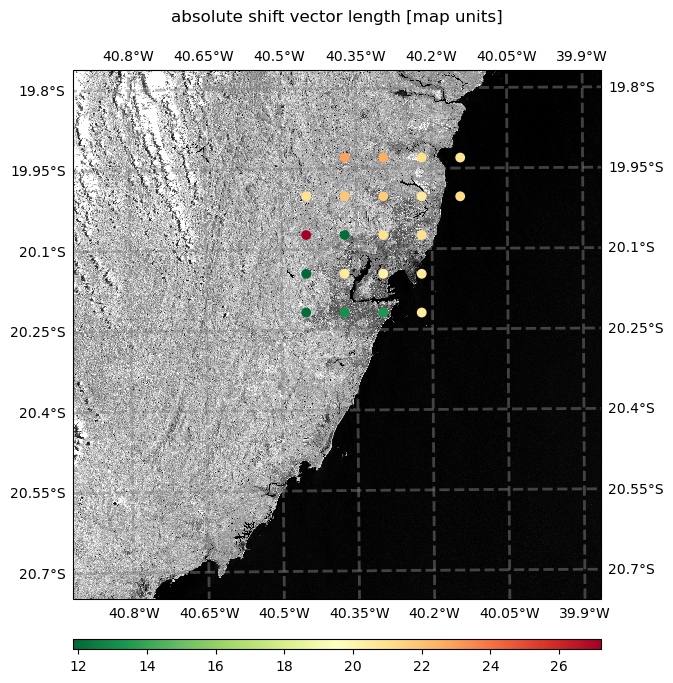

In [5]:
CRL.view_CoRegPoints(figsize=(7, 7), backgroundIm='ref')

### <span style="color:#336699">1.6 Visualização de Imagem (Depois do co-registro)</span>
<hr style="border:1px solid #0077b9;">

Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(300000.0, 7690240.0, 409800.0, 7800040.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for image to be shifted:
	(341056.0, 7743264.0, 456128.0, 7858688.0)
Matching window position (X,Y): 378923.63144130504/7777221.46942336
Note: array has been downsampled to 1000 x 1000 for faster visualization.
Initializing tie points grid...
Calculating tie point grid (44 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:03


Found 22 matches.
Performing validity checks...
1 tie points flagged by level 1 filtering (reliability).
15 tie points flagged by level 2 filtering (SSIM).
6 valid tie points remain after filtering.


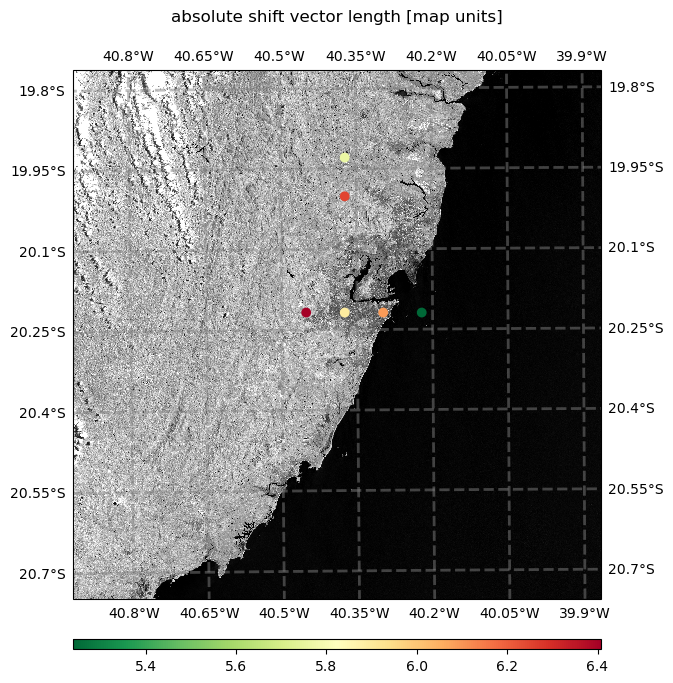

In [6]:
CRL_after_corr = COREG_LOCAL(geo_ref, caminho_saida_final, **kwargs)
CRL_after_corr.view_CoRegPoints(figsize=(7, 7), backgroundIm='ref')

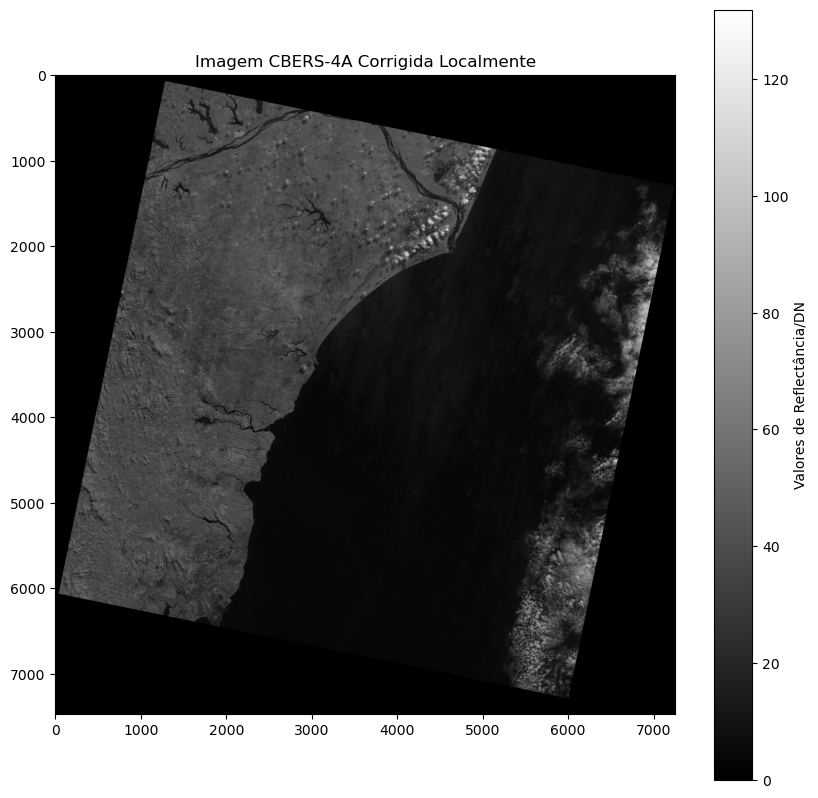

In [7]:
import rasterio
from matplotlib import pyplot as plt

# 1. Defina o caminho da imagem que você acabou de gerar
caminho_imagem = '/Users/carlaalmeida/Documents/python_qgis/Projeto/my_project/CBERS_corrigido_memoria.tif'

# 2. Abra o arquivo e leia a banda 1
with rasterio.open(caminho_imagem) as dataset:
    # Lendo os dados como uma matriz numérica do NumPy
    dados_imagem = dataset.read(1)
    
# 3. Plote a imagem usando o matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(dados_imagem, cmap='gray')  # Usamos 'gray' porque é uma banda única (tons de cinza)
plt.title("Imagem CBERS-4A Corrigida Localmente")
plt.colorbar(label='Valores de Reflectância/DN')
plt.axis('on')  # Mantém os eixos para você ver as coordenadas dos pixels
plt.show()

### <span style="color:#336699">1.7 Visualizacao da Imagem Corrigida</span>
<hr style="border:1px solid #0077b9;">

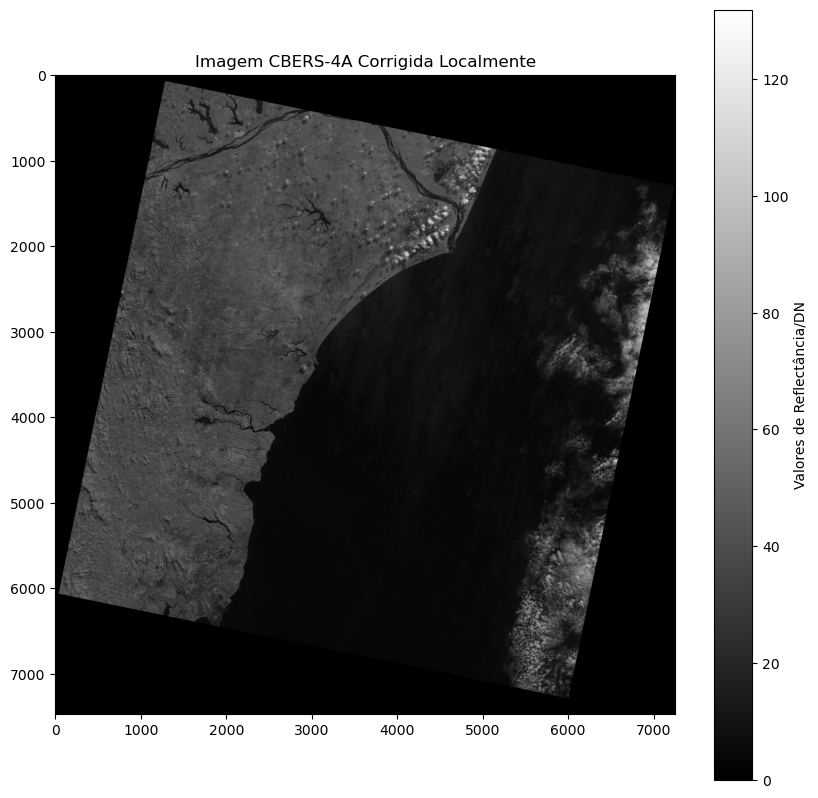

In [7]:
import rasterio
from matplotlib import pyplot as plt

# 1. Defina o caminho da imagem que você acabou de gerar
caminho_imagem = '/Users/carlaalmeida/Documents/python_qgis/Projeto/my_project/CBERS_corrigido_memoria.tif'

# 2. Abra o arquivo e leia a banda 1
with rasterio.open(caminho_imagem) as dataset:
    # Lendo os dados como uma matriz numérica do NumPy
    dados_imagem = dataset.read(1)
    
# 3. Plote a imagem usando o matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(dados_imagem, cmap='gray')  # Usamos 'gray' porque é uma banda única (tons de cinza)
plt.title("Imagem CBERS-4A Corrigida Localmente")
plt.colorbar(label='Valores de Reflectância/DN')
plt.axis('on')  # Mantém os eixos para você ver as coordenadas dos pixels
plt.show()

### <span style="color:#336699">Referência de Bibliográficas</span>
<hr style="border:1px solid #0077b9;">